<a href="https://colab.research.google.com/github/atul2017/Machine-Learning-Business-Cases/blob/main/Predicting_Sales_from_Campaign_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

df_train = pd.read_csv('messy_train_data.csv')
df_test = pd.read_csv('messy_test_data.csv')

Data Understanding

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Followers           7840 non-null   float64
 1   EngagementRate (%)  7840 non-null   object 
 2   AdSpend (GBP)       7841 non-null   object 
 3   ContentQuality      7840 non-null   float64
 4   Sales (Units)       8000 non-null   int64  
 5   ID                  8000 non-null   int64  
 6   Timestamp           8000 non-null   object 
 7   Notes               5348 non-null   object 
dtypes: float64(2), int64(2), object(4)
memory usage: 500.1+ KB


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Followers           1960 non-null   float64
 1   EngagementRate (%)  1960 non-null   object 
 2   AdSpend (GBP)       1960 non-null   object 
 3   ContentQuality      1960 non-null   float64
 4   ID                  2000 non-null   int64  
 5   Timestamp           2000 non-null   object 
 6   Notes               1340 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 109.5+ KB


In [ ]:
df_train.head(5)

,Followers,EngagementRate (%),AdSpend (GBP),ContentQuality,Sales (Units),FollowersInteractedWithAd,Spend_per_Follower,EngagementSpend
0,106572.0,3.0,2614.0,5.0,6340,3197.0,0.0,78.0
1,77583.0,1.0,4976.0,9.0,5793,776.0,0.0,50.0
2,92832.0,2.0,4108.0,6.0,8104,1857.0,0.0,82.0
3,53565.0,1.0,4293.0,4.0,7293,536.0,0.0,43.0
4,121079.0,3.0,5344.0,4.0,14396,3632.0,0.0,160.0


In [ ]:
df_test.head(5)

,Followers,EngagementRate (%),AdSpend (GBP),ContentQuality,ID,Timestamp,Notes
0,179136.0,2.5570425842061986,3975.099954173261,1.803620,6252,2021-10-08,Good
1,68888.0,3.451254744278324,5392.048613170361,2.993966,4684,2021-10-01,Good
2,89520.0,0.7342357926528821,5850.470394900652,4.525990,1731,2021-06-24,NaN
3,100048.0,1.5972073367018218,5792.432498712002,5.051500,4742,2021-11-22,NaN
4,132229.0,1.3874265375395036,5095.269891920688,3.580921,4521,2021-07-19,Review


In [ ]:
df_train.shape

(8000, 8)

In [ ]:
df_test.shape

(2000, 7)

In [ ]:
df_test['ID'].unique().size

2000

In [ ]:
df_train['ID'].unique().size

8000

In [ ]:
df_train['AdSpend (GBP)'].sort_values(ascending=False)

,AdSpend (GBP)
2924,£8517
7634,£8290
4325,£7920
1531,£7913
7286,£7907
...,...
7822,NaN
7868,NaN
7891,NaN
7941,NaN


In [ ]:
df_train['AdSpend (GBP)'].unique()

array(['2614.3781948587675', '4975.962514379572', '4107.769534318886',
       ..., '7103.543980175337', '3479.3093885454155',
       '4553.832868033651'], dtype=object)

In [ ]:
df_train['Notes'].unique()

array(['Pending', 'Review', nan, 'Good', 'Check'], dtype=object)

In [ ]:
df_train['Followers'].isna().sum()


np.int64(160)

In [ ]:
df_test['Followers'].isna().sum()

np.int64(40)

In [ ]:
df_train['EngagementRate (%)'].isna().sum()


np.int64(160)

In [ ]:
df_train['AdSpend (GBP)'].isna().sum()


np.int64(159)

In [ ]:
df_train['ContentQuality'].isna().sum()


np.int64(160)

In [ ]:
df_train['Notes'].isna().sum()


np.int64(2652)

Data Cleanup

In [ ]:
df_train.describe()

,Followers,ContentQuality,Sales (Units),ID
count,7.840000e+03,7840.000000,8000.000000,8000.000000
mean,1.111104e+06,5.492899,10544.674375,5011.506875
std,4.013038e+07,2.608038,2808.151485,2887.649416
min,2.000000e+01,1.000151,590.000000,1.000000
25%,7.800250e+04,3.227357,8642.250000,2511.750000
50%,9.912050e+04,5.468786,10500.000000,5013.500000
75%,1.198655e+05,7.780281,12459.000000,7504.250000
max,1.629447e+09,9.999749,20263.000000,9999.000000


In [ ]:
df_train['Sales (Units)'].dtype

dtype('int64')

In [ ]:
df_train["AdSpend (GBP)"] = (
    df_train["AdSpend (GBP)"]
    .str.replace("£", "", regex=False)
    .str.replace(",", "")
    .astype(float)
)

df_test["AdSpend (GBP)"] = (
    df_test["AdSpend (GBP)"]
    .str.replace("£", "", regex=False)
    .str.replace(",", "")
    .astype(float)
)


In [ ]:
# Clean discounted_price: keep only digits (and decimal if present), convert
df_train['EngagementRate (%)'] = pd.to_numeric(
    df_train['EngagementRate (%)'].astype(str).str.replace(',', '', regex=False),
    errors='coerce'
).astype(float)

df_test['EngagementRate (%)'] = pd.to_numeric(
    df_test['EngagementRate (%)'].astype(str).str.replace(',', '', regex=False),
    errors='coerce'
).astype(float)

In [ ]:
df_train["EngagementRate (%)"] = round(df_train["EngagementRate (%)"],0)
df_test["EngagementRate (%)"] = round(df_test["EngagementRate (%)"],0)

In [ ]:
df_train["AdSpend (GBP)"] = round(df_train["AdSpend (GBP)"],0)
df_test["AdSpend (GBP)"] = round(df_test["AdSpend (GBP)"],0)

In [ ]:
df_train["ContentQuality"] = round(df_train["ContentQuality"],0)
df_test["ContentQuality"] = round(df_test["ContentQuality"],0)


In [ ]:
df = df_train["AdSpend (GBP)"] < 0
df.sort_values(ascending=True).sum()

np.int64(3)

In [ ]:
df = df_train["EngagementRate (%)"] < 0
df.sort_values(ascending=True).sum()

np.int64(2)

In [ ]:
df = df_train["Sales (Units)"] < 0
df.sort_values(ascending=True).sum()

np.int64(0)

In [ ]:
df = df_train["ContentQuality"] < 0
df.sort_values(ascending=True).sum()

np.int64(0)

In [ ]:
df = df_train["Followers"] < 0
df.sort_values(ascending=True).sum()

np.int64(0)

In [ ]:
df_train.groupby(df_train["Notes"]).size()
df_test.groupby(df_test["Notes"]).size()

,0
Notes,
Check,364
Good,350
Pending,325
Review,301


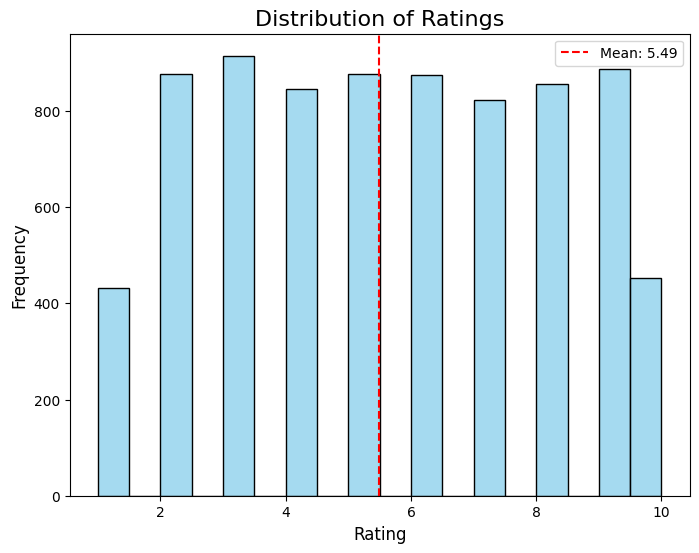

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram for 'rating'
plt.figure(figsize=(8, 6))
sns.histplot(data=df_train, x='ContentQuality', kde=False, color='skyblue')

# Styling Tip 💡
# Add a vertical line for the mean rating
mean_rating = df_train['ContentQuality'].mean()
plt.axvline(mean_rating, color='red', linestyle='--', label=f"Mean: {mean_rating:.2f}")

plt.title("Distribution of Ratings", fontsize=16)
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.show()

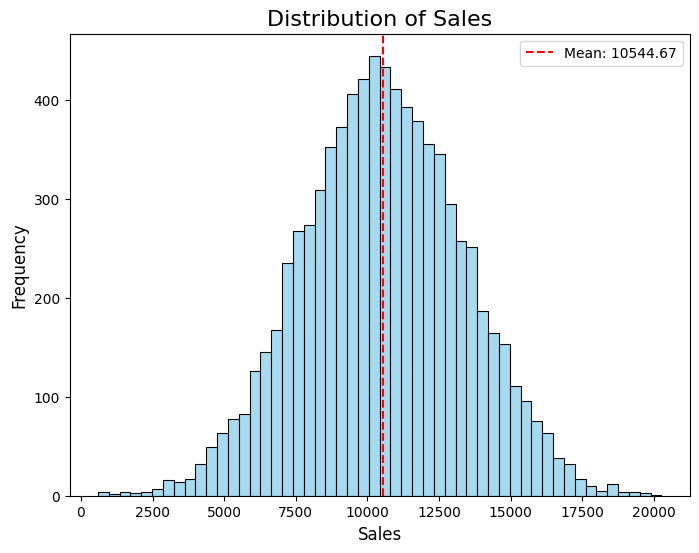

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram for 'rating'
plt.figure(figsize=(8, 6))
sns.histplot(data=df_train, x='Sales (Units)', kde=False, color='skyblue')

# Styling Tip 💡
# Add a vertical line for the mean rating
mean_rating = df_train['Sales (Units)'].mean()
plt.axvline(mean_rating, color='red', linestyle='--', label=f"Mean: {mean_rating:.2f}")

plt.title("Distribution of Sales", fontsize=16)
plt.xlabel("Sales", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.show()

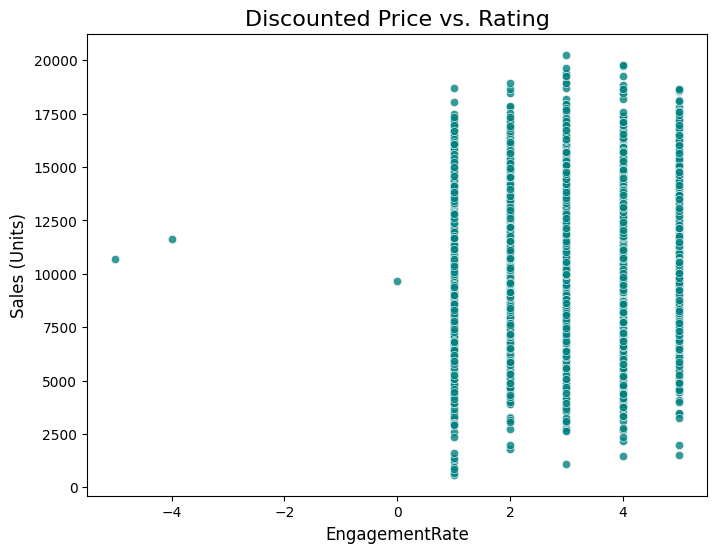

In [ ]:
plt.figure(figsize=(8, 6))

# Styling Tip 💡
# Use alpha to handle overlapping points
sns.scatterplot(data=df_train, x='EngagementRate (%)', y='Sales (Units)', color='teal', alpha = 0.8)

plt.title("Discounted Price vs. Rating", fontsize=16)
plt.xlabel("EngagementRate", fontsize=12)
plt.ylabel("Sales (Units)", fontsize=12)
plt.show()

In [ ]:
df_train.shape

(8000, 8)

In [ ]:
df_test.shape

(2000, 7)

In [ ]:
df_train.dropna(subset=["Followers", "EngagementRate (%)","AdSpend (GBP)","ContentQuality"],inplace=True)

In [ ]:
df_test['ContentQuality'].isna().sum()


np.int64(40)

In [ ]:
df_test['Followers'].isna().sum()

np.int64(40)

In [ ]:
df_test['EngagementRate (%)'].isna().sum()

np.int64(240)

In [ ]:
df_test['AdSpend (GBP)'].isna().sum()

np.int64(40)

Considering there is only 10% loss of my train data when I drop rows for above columns having NaN I will consider this approach.

Also, I am not considering the Notes at this moment which contains lot of rows with NaN and I am not able to understand the meaning of it I am droping this column for my model buidling.

In [ ]:
df_train.drop(columns=['Notes'], inplace=True)


In [ ]:
df_test.drop(columns=['Notes'], inplace=True)


In [ ]:
df_test.shape

(2000, 6)

In [ ]:
#Deleting outliers - billions of followers
df_test = df_test[df_test['Followers'] <= 200000]

In [ ]:
#Deleting outliers - billions of followers
df_train = df_train[df_train['Followers'] <= 200000]

In [ ]:
#Deleting outliers - billions in spends which is not logical
df_train = df_train[df_train['AdSpend (GBP)'] <= 10000]

In [ ]:
#Deleting outliers - billions in spends which is not logical
df_test = df_test[df_test['AdSpend (GBP)'] <= 10000]

In [ ]:
#Deleting outliers - negative spending
#df_test = df_test[df_test['EngagementRate (%)'] > 0]


In [ ]:
#Deleting outliers - negative engagement rate
df_train = df_train[df_train['EngagementRate (%)'] > 0]


In [ ]:
df_train.shape

(7177, 7)

In [ ]:
df_test['EngagementRate (%)'] = df_test['EngagementRate (%)'].fillna(df_test['EngagementRate (%)'].median())
df_test['ContentQuality'] = df_test['ContentQuality'].fillna(df_test['ContentQuality'].median())
df_test['AdSpend (GBP)'] = df_test['AdSpend (GBP)'].fillna(df_test['AdSpend (GBP)'].median())


In [ ]:
df_test.shape

(1912, 6)

Explority Data Analysis (EDA)
Identify the best performing Ad Campaign based on Sales.

Identify pattern between best ad campaign and engagement rates.

Identify pattern between Ad Spend and best performing ad campaign data.

Identify pattern between Content Quality and best performing ad campaign data.

Define different tier campagin based unit sold - Platinum, Gold, Silver, Bronze to explore the data. I am not going to use this in the model.




In [ ]:
def segment_campaign(sales):
    if sales >= 15000:
        return 'Platinum'
    elif sales >= 10000:
        return 'Gold'
    elif sales >= 7500:
        return 'Silver'
    else:
        return 'Bronze'

df_train['Segment'] = df_train['Sales (Units)'].apply(segment_campaign)


In [ ]:
df_train.groupby('Segment')['ID'].count().sort_values(ascending=True).reset_index()

,Segment,ID
0,Platinum,408
1,Bronze,998
2,Silver,2032
3,Gold,3739


In [ ]:
df_train.groupby('Segment')['AdSpend (GBP)'].sum().sort_values(ascending=True).reset_index()

,Segment,AdSpend (GBP)
0,Platinum,2558654.0
1,Bronze,4014580.0
2,Silver,9364310.0
3,Gold,19812180.0


In [ ]:
df_train.groupby('Segment')['Sales (Units)'].sum().sort_values(ascending=True).reset_index()

,Segment,Sales (Units)
0,Bronze,6072658
1,Platinum,6579577
2,Silver,18011362
3,Gold,45003771


In [ ]:
df_train.groupby('Segment')['EngagementRate (%)'].mean().sort_values(ascending=True).reset_index()

,Segment,EngagementRate (%)
0,Bronze,2.679359
1,Silver,2.733268
2,Gold,2.876438
3,Platinum,2.936275


In [ ]:
df_train.groupby('Segment')['ContentQuality'].mean().sort_values(ascending=True).reset_index()

,Segment,ContentQuality
0,Bronze,4.691383
1,Silver,5.223425
2,Gold,5.777748
3,Platinum,6.414216


In [ ]:
df_train.groupby('Segment')['Followers'].mean().sort_values(ascending=True).reset_index()

,Segment,Followers
0,Bronze,72083.934870
1,Silver,88261.151575
2,Gold,106375.486494
3,Platinum,130560.593137


Explority Data Insight-

Top tier campaigns which are generating more then 15000 unit sales have highest content quality.

Highest quality content has highest engagement rate.

Number of followers matters but quality of contetn is driving more slaes. For example Silver and Gold have more followers compare to Plaitnum but still not
generating the sales and not the top ad campaigns.

Top sales number which is greater > 15000 are hit by platinum campaigns which has least AD Spend but content quality, Engagement rates are very high.

Feature Engineering

Creating a new column which shows how many followers actually interacted with the ad based on the formula = 	(Followers*EngagementRate (%))/100

In [ ]:
df_train['FollowersInteractedWithAd'] = (df_train["Followers"]*df_train["EngagementRate (%)"])/100

In [ ]:
df_train['FollowersInteractedWithAd'] = round(df_train['FollowersInteractedWithAd'],0)

In [ ]:
df_test['FollowersInteractedWithAd'] = (df_test["Followers"]*df_test["EngagementRate (%)"])/100

In [ ]:
df_test['FollowersInteractedWithAd'] = round(df_test['FollowersInteractedWithAd'],0)

In [ ]:
df_train.groupby('Segment')['FollowersInteractedWithAd'].mean().sort_values(ascending=True).reset_index()

,Segment,FollowersInteractedWithAd
0,Bronze,1928.056112
1,Silver,2377.114173
2,Gold,3047.847018
3,Platinum,3801.225490


Adding new feature called spending per follower to see if this helps improving our

In [ ]:
df_train['Spend_per_Follower'] = df_train['AdSpend (GBP)'] / df_train['Followers']

df_train['Spend_per_Follower'] = round(df_train['Spend_per_Follower'],0)

In [ ]:
df_test['Spend_per_Follower'] = df_test['AdSpend (GBP)'] / df_test['Followers']

df_test['Spend_per_Follower'] = round(df_test['Spend_per_Follower'],0)

Adding another new feature called engagement spend = EngagementRate * ASpend

In [ ]:
df_train['EngagementSpend'] = (df_train['EngagementRate (%)'] * df_train['AdSpend (GBP)'])/100

df_train['EngagementSpend'] = round(df_train['EngagementSpend'],0)

In [ ]:
df_test['EngagementSpend'] = (df_test['EngagementRate (%)'] * df_test['AdSpend (GBP)'])/100

df_test['EngagementSpend'] = round(df_test['EngagementSpend'],0)

Trying simple regression model first


In [ ]:
df_test.drop(columns=['Timestamp','ID'], axis =1,inplace=True)

In [ ]:
df_test.shape

(1912, 7)

In [ ]:
df_train.drop(columns=['ID','Timestamp','Segment'],inplace=True)

In [ ]:
df_train.shape

(7177, 8)

In [ ]:
df_test.shape

(1912, 7)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import skew

In [ ]:
#Define feature and target

features= ['Followers','EngagementRate (%)','AdSpend (GBP)','ContentQuality','FollowersInteractedWithAd','Spend_per_Follower','EngagementSpend']
X = df_train[features]
#Target
y = df_train['Sales (Units)']

X_test_final = df_test[features]
#Train/Validation split (for evaluation)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#Scaling features since variance is very high
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test_final)
#Train baseline linear regression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
#evaluate model
y_val_pred = model.predict(X_val_scaled)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)
print(f"Validation RMSE: {rmse:.2f}")
print(f"Validation R²: {r2:.2f}")

Validation RMSE: 2064.70
Validation R²: 0.46


In [ ]:
#Train final model on full training data
X_full_scaled = scaler.fit_transform(X)
model.fit(X_full_scaled, y)

LinearRegression()

In [ ]:
#PRedicting sales for test data
df_test['Predicted_Sales'] = model.predict(X_test_scaled)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None
)

rf.fit(X_train, y_train)
y_val_pred = rf.predict(X_val)

print("R²:", r2_score(y_val, y_val_pred))

R²: 0.4554825907486334


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

#gbr = GradientBoostingRegressor(random_state=42)
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

gbr.fit(X_train, y_train)

y_val_pred = gbr.predict(X_val)
print("R²:", r2_score(y_val, y_val_pred))


R²: 0.497833685511502


E: Model Evaluation & Tuning - Added two more new features later which are Spend_per_Follower and EngagementSpend to see if it makes difference in RMSE and R2. There is neglible difference.

Used GradientBoostingRegressor and fine tune with parameter which increased the R2 value by 1.

Business Insights & Pipeline Design

(1) AdSpend matters but based on the exploration platinum segment has the least adspend but the number of interactions are highest among the followers. It means the content of the add probably does not matter but the outreach is important. This is with the assumption that ad campaign money is distributed in content creation and outreach.

(2) Futher there can be more analysis done when the campaign is ending. This might have some significance with unit sold if the interaction happening on month end or mid of the month when people get paychecks.

(3) The followers number matters. More followers increases the probability of interacting with the add camppaign.

(4) Content quality matters because platinum where the most sales took place have the highest average content quality among all segments.
